# 1.Carga y exploración inicial datos

In [1]:
# ======================
# 1.1 Importar Librerías
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap

In [2]:
# ==============================================================
# 1.2 Cargar dataset (ajusta la ruta)
# ==============================================================
import os
from pathlib import Path
import platform
import pandas as pd

# Detectar sistema operativo
so = platform.system()  # Devuelve 'Windows', 'Darwin' (Mac) o 'Linux'

if so == "Windows":
    project_dir = Path(r"D:\Cursos\Data_Analytics\Portfolio\Portfolio_Github\Proyecto_Telco_Customer")
elif so == "Darwin":  # Mac
    project_dir = Path("/Users/danielalvarezmiguez/Desktop/Portfolio-Power-Bi/Proyecto_Telco_Customer")
else:
    raise Exception("Sistema operativo no soportado")

# Ruta al CSV dentro de Data
csv_path = project_dir / "Data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Verifica que exista
print("Ruta CSV:", csv_path)
print("Existe?", csv_path.exists())

# Leer CSV
if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"No se encontró el archivo CSV en {csv_path}")

Ruta CSV: D:\Cursos\Data_Analytics\Portfolio\Portfolio_Github\Proyecto_Telco_Customer\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Existe? True


In [3]:
# ==============================================================
# 1.3 Ver número filas y columnas
# ==============================================================
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (7043, 21)


In [4]:
# ==============================================================
# 1.4 Ver primeras filas
# ==============================================================
print(df.head(20).to_string())

    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0   7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL                   No                  Yes                   No                   No                   No                   No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1   5575-GNVDE    Male              0      No         No      34          Yes                No             DSL                  Yes                   No                  Yes                   No                   No                   No        One year               No               Mailed check           56.95       1889.5    No
2

In [5]:
# ==============================================================
# 1.5 Ver tipos de datos
# ==============================================================
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# ==============================================================
# 1.6 Ver valores nulos por columna
# ==============================================================
# Total de filas
total_filas = len(df)

# Conteo de nulos
nulos = df.isnull().sum()

# Porcentaje de nulos
porcentaje_nulos = (nulos / total_filas) * 100

# Mostrar como DataFrame ordenado
resultado = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print(resultado)

                  Nulos  Porcentaje (%)
customerID            0             0.0
gender                0             0.0
SeniorCitizen         0             0.0
Partner               0             0.0
Dependents            0             0.0
tenure                0             0.0
PhoneService          0             0.0
MultipleLines         0             0.0
InternetService       0             0.0
OnlineSecurity        0             0.0
OnlineBackup          0             0.0
DeviceProtection      0             0.0
TechSupport           0             0.0
StreamingTV           0             0.0
StreamingMovies       0             0.0
Contract              0             0.0
PaperlessBilling      0             0.0
PaymentMethod         0             0.0
MonthlyCharges        0             0.0
TotalCharges          0             0.0
Churn                 0             0.0


# 2.Limpieza de datos

In [7]:
# ==============================================================
# 2.1 Pasar TotalCharges a numérico (tiene espacios vacíos)
# ==============================================================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [8]:
# ==============================================================
# 2.2 Eliminar customerID
# ==============================================================
# Guardamos customerID antes de eliminarlo
customer_ids = df["customerID"].copy()  # copia de la columna original

# Ahora podemos eliminar la columna para ML
df.drop("customerID", axis=1, inplace=True)

In [9]:
# ==============================================================
# 2.3 Renombrar columnas
# ==============================================================
df.rename(columns={
    "gender": "Género",
    "SeniorCitizen": "Adulto_Mayor",
    "Partner": "Pareja",
    "Dependents": "Dependientes",
    "tenure": "Meses_Contrato",
    "PhoneService": "Servicio_Teléfono",
    "MultipleLines": "Lineas_Adicionales",
    "InternetService": "Servicio_Internet",
    "OnlineSecurity": "Seguridad_Online",
    "OnlineBackup": "Backup_Online",
    "DeviceProtection": "Protección_Dispositivo",
    "TechSupport": "Soporte_Técnico",
    "StreamingTV": "Streaming_TV",
    "StreamingMovies": "Streaming_Películas",
    "Contract": "Tipo_Contrato",
    "PaperlessBilling": "Factura_Electrónica",
    "PaymentMethod": "Método_Pago",
    "MonthlyCharges": "Cobro_Mensual",
    "TotalCharges": "Cobro_Total",
    "Churn": "Cliente_Baja"
}, inplace=True)


In [10]:
# ==============================================================
# 2.4 Ver valores únicos en las columnas
# ==============================================================
columnas = [
    "Género", "Adulto_Mayor", "Pareja", "Dependientes", "Servicio_Teléfono",
    "Lineas_Adicionales", "Servicio_Internet", "Seguridad_Online",
    "Backup_Online", "Protección_Dispositivo", "Soporte_Técnico",
    "Streaming_TV", "Streaming_Películas", "Tipo_Contrato",
    "Factura_Electrónica", "Método_Pago", "Cliente_Baja"
]

for col in columnas:
    valores = df[col].unique().tolist()
    print(f"\n--- {col} ---")
    # si hay más de 20 valores, solo mostramos los primeros
    if len(valores) > 20:
        print(valores[:20], "...")  
        print(f"(Total de valores únicos: {len(valores)})")
    else:
        print(valores)



--- Género ---
['Female', 'Male']

--- Adulto_Mayor ---
[0, 1]

--- Pareja ---
['Yes', 'No']

--- Dependientes ---
['No', 'Yes']

--- Servicio_Teléfono ---
['No', 'Yes']

--- Lineas_Adicionales ---
['No phone service', 'No', 'Yes']

--- Servicio_Internet ---
['DSL', 'Fiber optic', 'No']

--- Seguridad_Online ---
['No', 'Yes', 'No internet service']

--- Backup_Online ---
['Yes', 'No', 'No internet service']

--- Protección_Dispositivo ---
['No', 'Yes', 'No internet service']

--- Soporte_Técnico ---
['No', 'Yes', 'No internet service']

--- Streaming_TV ---
['No', 'Yes', 'No internet service']

--- Streaming_Películas ---
['No', 'Yes', 'No internet service']

--- Tipo_Contrato ---
['Month-to-month', 'One year', 'Two year']

--- Factura_Electrónica ---
['Yes', 'No']

--- Método_Pago ---
['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

--- Cliente_Baja ---
['No', 'Yes']


In [11]:
# ==============================================================
# 2.5 Convertir variables categóricas
# ==============================================================
# Columnas categóricas binarias
cat_cols_bin = [col for col in df.select_dtypes(include=["object"]).columns if df[col].nunique() == 2]

# Guardamos encoders para revertir
encoders = {}

for col in cat_cols_bin:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Columnas categóricas con más de 2 categorías
cat_cols_multi = [col for col in df.select_dtypes(include=["object"]).columns if df[col].nunique() > 2]

# Creamos un dataframe temporal con dummies
df_dummies = pd.get_dummies(df[cat_cols_multi], drop_first=True)

# Concatenamos las columnas dummy al dataframe original y eliminamos las originales de categoría múltiple
df = pd.concat([df.drop(columns=cat_cols_multi), df_dummies], axis=1)

In [12]:
# ==============================================================
# 2.6 Reemplaza espacios, guiones y palabras en inglés
# ==============================================================
df.columns = [c.replace(" ", "_").replace("-", "_")
              .replace("No_internet_service", "Sin_Internet")
              .replace("Fiber_optic", "Fibra")
              .replace("Yes", "Si") for c in df.columns]

# Guardar columnas finales en español
columnas = df.drop("Cliente_Baja", axis=1).columns

# 3. Separar X / Y

In [13]:
# ==============================================================
# 3. Separar X / Y
# ==============================================================
X = df.drop("Cliente_Baja", axis=1)
y = df["Cliente_Baja"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 4. Modelos

In [14]:
# ==============================================================
# 4.1 Logistic Regression
# ==============================================================
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8416931462967269


In [15]:
# ==============================================================
# 4.2 Random Forest
# ==============================================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8241210054509287


In [16]:
# ==============================================================
# 4.3 XGBoost
# ==============================================================
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8214291250096877


# 5. Interpretabilidad

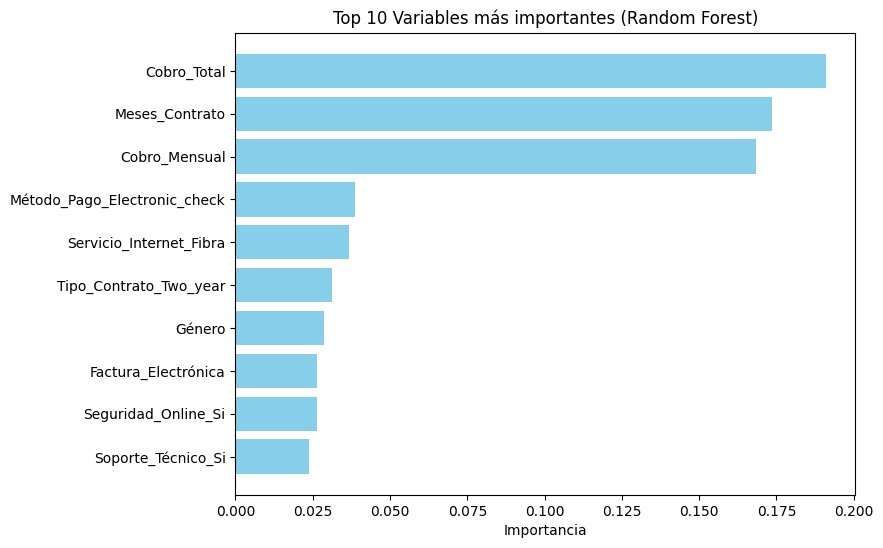

In [17]:
# ==============================================================
# 5.1 Feature importance - Random Forest
# ==============================================================
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices], align="center", color='skyblue')
plt.yticks(range(len(indices)), [columnas[i] for i in indices])
plt.xlabel("Importancia")
plt.title("Top 10 Variables más importantes (Random Forest)")
plt.show()

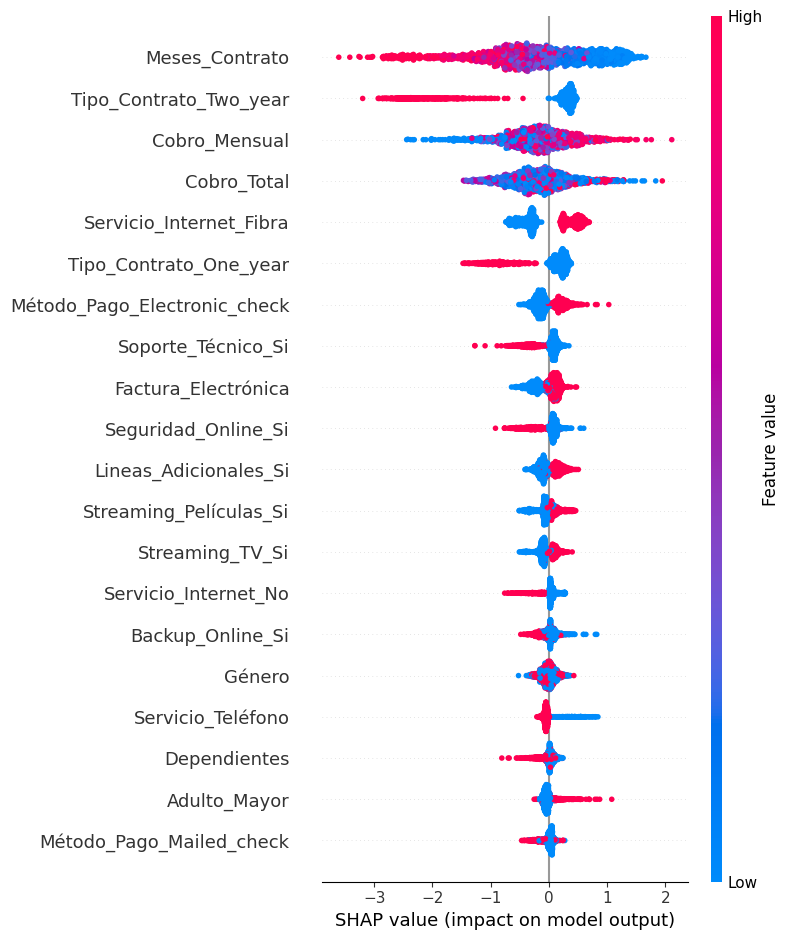

In [18]:
# ==============================================================
# 5.2 SHAP para XGBoost
# ==============================================================
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=columnas)

# 6. Columna de predicción tras entrenamiento del modelo

In [19]:
# Probabilidad de churn
df["Probabilidad_Baja"] = xgb.predict_proba(X_scaled)[:,1]

# Predicción final (0 = no churn, 1 = churn)
df["Prediccion_Baja"] = xgb.predict(X_scaled)

# 7 Revertir Columnas Binarias

In [20]:
cols_originales = ["Género", "Pareja", "Dependientes", "Servicio_Teléfono", "Factura_Electrónica"]

for col in cols_originales:
    df[col] = encoders[col].inverse_transform(df[col])

# 8 Recuperamos CustomerID

In [21]:
# Reinsertar customerID para el CSV final
df["customerID"] = customer_ids.values
df.rename(columns={"customerID": "ClienteID"}, inplace=True)

# 8 Guardar Dataset limpio

In [22]:
# Ruta de salida del CSV con predicciones
output_csv = project_dir / "Data" / "Predicciones_Telco.csv"

# Crear carpeta Data si no existe
output_csv.parent.mkdir(parents=True, exist_ok=True)

# Guardar CSV
df.to_csv(
    output_csv,
    index=False,
    sep=";",        # Power BI en español suele usar punto y coma
    decimal=".",    # números decimales con punto
    encoding="utf-8-sig"
)

print("CSV guardado en:", output_csv)


CSV guardado en: D:\Cursos\Data_Analytics\Portfolio\Portfolio_Github\Proyecto_Telco_Customer\Data\Predicciones_Telco.csv


# 9 Guardar CSV con el ranking de variables más importantes

In [23]:
# Crear DataFrame con variables e importancia
df_importance = pd.DataFrame({
    'Variable': columnas,                 # nombres de columnas usadas en el modelo
    'Importancia': rf.feature_importances_
})

# Ordenar de mayor a menor
df_importance = df_importance.sort_values(by='Importancia', ascending=False)

# Guardar solo el top 10
top10_rf = df_importance.head(10)

# Ruta de salida
output_top10_rf = project_dir / "Data" / "Top10_Variables_RF.csv"

# Crear carpeta si no existe
output_top10_rf.parent.mkdir(parents=True, exist_ok=True)

# Guardar CSV
top10_rf.to_csv(output_top10_rf, index=False, sep=";", decimal=".", encoding="utf-8-sig")

print("CSV Top 10 RF guardado en:", output_top10_rf)


CSV Top 10 RF guardado en: D:\Cursos\Data_Analytics\Portfolio\Portfolio_Github\Proyecto_Telco_Customer\Data\Top10_Variables_RF.csv
